# Axion Response

In [1]:
import numpy as np
from pathlib import Path

from pythtb import W90
from pythtb.utils import finite_diff_coeffs, levi_civita
from tensorflow import constant as const, complex64
import tensorflow as tf
import tensorflow.linalg as tfla
import matplotlib.pyplot as plt

In [35]:
def vel_fd(H_k, mu, dk_mu, order_eps, mode="central"):
    coeffs, stencil = finite_diff_coeffs(order=order_eps, mode=mode)
    fd_sum = np.zeros_like(H_k)
    for s, c in zip(stencil, coeffs):
        fd_sum += c * np.roll(H_k, shift=-s, axis=mu)
    return fd_sum / dk_mu

def berry_curvature(v_k, H_flat, occ_idxs):
    H_flat_tf = const(H_flat, dtype=complex64)
    v_k_tf = const(v_k, dtype=complex64)

    evals_tf, evecs_tf = tfla.eigh(H_flat_tf)
    evecs_tf = tf.transpose(evecs_tf, perm=[0, 1, 3, 2])
    evecs_T_tf = tf.transpose(evecs_tf, perm=[0, 1, 3, 2])
    evecs_conj_tf = tf.math.conj(evecs_tf)

    v_k_rot_tf = tf.matmul(
        evecs_conj_tf[None, :, :, :, :],
        tf.matmul(v_k_tf, evecs_T_tf[None, :, :, :, :])
    )

    n_eigs = evals_tf.shape[-1]
    occ_idxs = np.array(occ_idxs)

    cond_idxs = np.setdiff1d(np.arange(n_eigs), occ_idxs)

    delta_E_tf = evals_tf[..., None, :] - evals_tf[..., :, None]
    delta_E_occ_cond_tf = tf.gather(tf.gather(delta_E_tf, occ_idxs, axis=-2), cond_idxs, axis=-1)
    delta_E_cond_occ_tf = tf.gather(tf.gather(delta_E_tf, cond_idxs, axis=-2), occ_idxs, axis=-1)

    inv_delta_E_occ_cond_tf = 1 / delta_E_occ_cond_tf
    inv_delta_E_cond_occ_tf = 1 / delta_E_cond_occ_tf

    v_occ_cond_tf = tf.gather(tf.gather(v_k_rot_tf, occ_idxs, axis=-2), cond_idxs, axis=-1)
    v_cond_occ_tf = tf.gather(tf.gather(v_k_rot_tf, cond_idxs, axis=-2), occ_idxs, axis=-1)
    v_occ_cond_tf = v_occ_cond_tf * inv_delta_E_occ_cond_tf
    v_cond_occ_tf = v_cond_occ_tf * -inv_delta_E_cond_occ_tf

    Q = tf.matmul(v_occ_cond_tf[:, None], v_cond_occ_tf[None, :]).numpy()
    return 1j * (Q - np.swapaxes(Q, -1, -2).conj())

In [36]:
# Material
material = "Y2Ir2O7"

# base calculaton
U_value = "u_3.0"
base_out_folder = "158009bc889"

# phonon symmetry mode
irrep = "GM2-"
mode = "mode3"
amp = "Q_0.01A"
phonon_out_folder = "157398bc889"

DATA = Path("../../data/Y2Ir2O7/phonon")  # the runs; this folder holds only code
base_dir = DATA.parent / (f"base/soc/{U_value}/output/{base_out_folder}")
mode_dir = DATA / (f"{irrep}/{mode}/{amp}/output/{phonon_out_folder}")
out_dir = mode_dir / "nk_sweep"

In [37]:
required = [
    Path(f"{mode_dir}/{material}_hr.dat"),
    Path(f"{mode_dir}/{material}.win"),
    Path(f"{base_dir}/{material}_hr.dat"),
    Path(f"{base_dir}/{material}.win"),
]

missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required files:\n" + "\n".join(missing)
    )

print("Found all required files.")

Found all required files.


In [38]:
print("Loading Wannier90 models...")
w90_base = W90(base_dir, r"Y2Ir2O7")
w90_mode1 = W90(mode_dir, r"Y2Ir2O7")

print("Building PythTB models...")
model_base = w90_base.model(
    zero_energy=0,
    min_hopping_norm=1e-5,
    max_distance=125,
    ignorable_imaginary_part=None,
)

model_mode3 = w90_mode1.model(
    zero_energy=0,
    min_hopping_norm=1e-5,
    max_distance=125,
    ignorable_imaginary_part=None,
)

models = [model_base, model_mode3]
print("norb:", model_base.norb)

Loading Wannier90 models...
Building PythTB models...
norb: 164


In [39]:
nk = 16
k_mesh = model_base.k_uniform_mesh([nk, nk, nk], include_endpoints=False)

# One mode pair: [base (beta=0), mode_1 (beta=1)]
H = np.zeros((1, k_mesh.shape[0], 2, model_base.norb, model_base.norb), dtype=np.complex64)
v_k = np.zeros((1, 3, k_mesh.shape[0], 2, model_base.norb, model_base.norb), dtype=np.complex64)

print(f"Filling base (beta=0) and {mode} (beta=1)...")
batch_size = 50
for i in range(0, len(k_mesh), batch_size):
    print(f"{i} / {len(k_mesh)} k points processed")
    k_batch = k_mesh[i:i + batch_size]

    H_base = model_base.hamiltonian(k_batch, flatten_spin_axis=True)
    v_base = model_base.velocity(k_batch, flatten_spin_axis=True)
    H_mode1 = model_mode3.hamiltonian(k_batch, flatten_spin_axis=True)
    v_mode1 = model_mode3.velocity(k_batch, flatten_spin_axis=True)

    H[0, i:i + batch_size, 0, :, :] = H_base
    H[0, i:i + batch_size, 1, :, :] = H_mode1
    v_k[0, :, i:i + batch_size, 0, :, :] = v_base
    v_k[0, :, i:i + batch_size, 1, :, :] = v_mode1

v_beta = vel_fd(H, mu=2, dk_mu=0.01, order_eps=1, mode="forward")
v = np.concatenate((v_k, v_beta[:, np.newaxis, ...]), axis=1)
print("H shape:", H.shape, "v shape:", v.shape)

Filling base (beta=0) and mode3 (beta=1)...
0 / 4096 k points processed
50 / 4096 k points processed
100 / 4096 k points processed
150 / 4096 k points processed
200 / 4096 k points processed
250 / 4096 k points processed
300 / 4096 k points processed
350 / 4096 k points processed
400 / 4096 k points processed
450 / 4096 k points processed
500 / 4096 k points processed
550 / 4096 k points processed
600 / 4096 k points processed
650 / 4096 k points processed
700 / 4096 k points processed
750 / 4096 k points processed
800 / 4096 k points processed
850 / 4096 k points processed
900 / 4096 k points processed
950 / 4096 k points processed
1000 / 4096 k points processed
1050 / 4096 k points processed
1100 / 4096 k points processed
1150 / 4096 k points processed
1200 / 4096 k points processed
1250 / 4096 k points processed
1300 / 4096 k points processed
1350 / 4096 k points processed
1400 / 4096 k points processed
1450 / 4096 k points processed
1500 / 4096 k points processed
1550 / 4096 k poin

In [40]:
print(f"Computing symmetrized axion response for {mode} (batched)...")

epsilon = levi_civita(4, 4)
Nk = H.shape[1]
n_occ = 104
occ = np.arange(n_occ)

# store only reduced density per k, beta
chern2_flat = np.zeros((Nk, 2), dtype=np.complex64)

k_batch = 32  # try 16 if still memory-heavy
for i in range(0, Nk, k_batch):
    j = min(i + k_batch, Nk)
    print(f"k-batch {i}:{j} / {Nk}")

    # slice: v[mode=0, dir, k, beta, n, n], H[mode=0, k, beta, n, n]
    b_curv_batch = berry_curvature(v[0, :, i:j, :, :, :], H[0, i:j, :, :, :], occ_idxs=range(n_occ))

    chern2_flat[i:j] = (
        np.einsum("ijkl,ij...mn,kl...nm->...", epsilon, b_curv_batch, b_curv_batch)
        * (1 / (16 * np.pi))
    )

    del b_curv_batch

Computing symmetrized axion response for mode3 (batched)...
k-batch 0:32 / 4096
k-batch 32:64 / 4096
k-batch 64:96 / 4096
k-batch 96:128 / 4096
k-batch 128:160 / 4096
k-batch 160:192 / 4096
k-batch 192:224 / 4096
k-batch 224:256 / 4096
k-batch 256:288 / 4096
k-batch 288:320 / 4096
k-batch 320:352 / 4096
k-batch 352:384 / 4096
k-batch 384:416 / 4096
k-batch 416:448 / 4096
k-batch 448:480 / 4096
k-batch 480:512 / 4096
k-batch 512:544 / 4096
k-batch 544:576 / 4096
k-batch 576:608 / 4096
k-batch 608:640 / 4096
k-batch 640:672 / 4096
k-batch 672:704 / 4096
k-batch 704:736 / 4096
k-batch 736:768 / 4096
k-batch 768:800 / 4096
k-batch 800:832 / 4096
k-batch 832:864 / 4096
k-batch 864:896 / 4096
k-batch 896:928 / 4096
k-batch 928:960 / 4096
k-batch 960:992 / 4096
k-batch 992:1024 / 4096
k-batch 1024:1056 / 4096
k-batch 1056:1088 / 4096
k-batch 1088:1120 / 4096
k-batch 1120:1152 / 4096
k-batch 1152:1184 / 4096
k-batch 1184:1216 / 4096
k-batch 1216:1248 / 4096
k-batch 1248:1280 / 4096
k-batch 128

In [41]:
chern2_density = chern2_flat.reshape((nk, nk, nk, 2))

# d3k = 1 / ((nk-1)**3)
d3k = 1 / (nk ** 3)

dtheta = np.sum(chern2_density, axis=(0, 1, 2)) * d3k

print("dtheta (base -> symmetrized " + mode + "):", dtheta)

dtheta (base -> symmetrized mode3): [-0.19833727+4.3678267e-20j  0.22493275-9.0996401e-20j]


dtheta (base -> symmetrized mode3): [0.18471967+3.7645568e-20j 0.13796614+1.0818445e-20j]

In [42]:
rho = chern2_density[..., 0].real

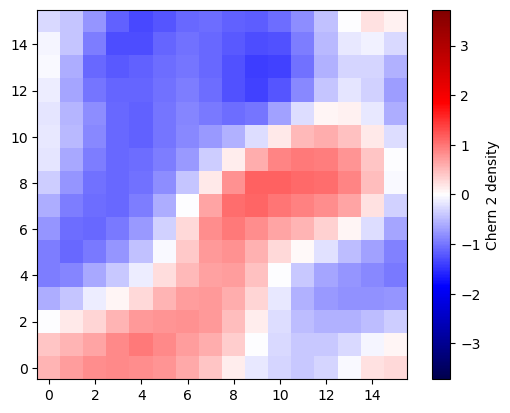

In [51]:
plt.imshow(rho[nk//2, :, :], origin='lower', cmap='seismic', vmax=np.abs(rho).max(), vmin=-np.abs(rho).max())
plt.colorbar(label="Chern 2 density")